<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Like_Packet_Internal_Orientation_V4b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Electron-Like Packet — Internal Orientation V4b

Repair notebook for the V4 failure mode. V3b established:

\[
(N_+,N_0,N_-)\simeq(0,1,3),\qquad q_{\rm eff}\simeq -1.
\]

V4 showed the Pauli/SU(2) algebraic scaffold works, but the relaxed orientation only reached weak sectors \(p\simeq\pm0.25\).

V4b strengthens the orientation-sector lock to test whether the fixed electron-like packet can support:

\[
p_+>0.95,\qquad p_-<-0.95,
\]

with near-degenerate energy, perturbation recovery, and Pauli/SU(2) checks.


In [1]:
# ============================================================
# CELL 1 — SETUP
# ============================================================

import json, math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT = Path("ecsm_electron_like_internal_orientation_v4b_out")
OUT.mkdir(exist_ok=True)

def trapz(y, x):
    return np.trapezoid(y, x)

np.set_printoptions(precision=8, suppress=True)
print("Output folder:", OUT.resolve())


Output folder: /content/ecsm_electron_like_internal_orientation_v4b_out


{
  "N_plus": 0.0009716378827065886,
  "N_zero": 1.000146008084612,
  "N_minus": 2.998882354032682,
  "scale": 0.041787044210350933,
  "raw_norm": 95.7234491117506,
  "count_total": 4.0,
  "q_eff": -0.9993035720499918,
  "R_rms": 5.236462555204353,
  "N_grid": 420,
  "r_max": 12.0
}


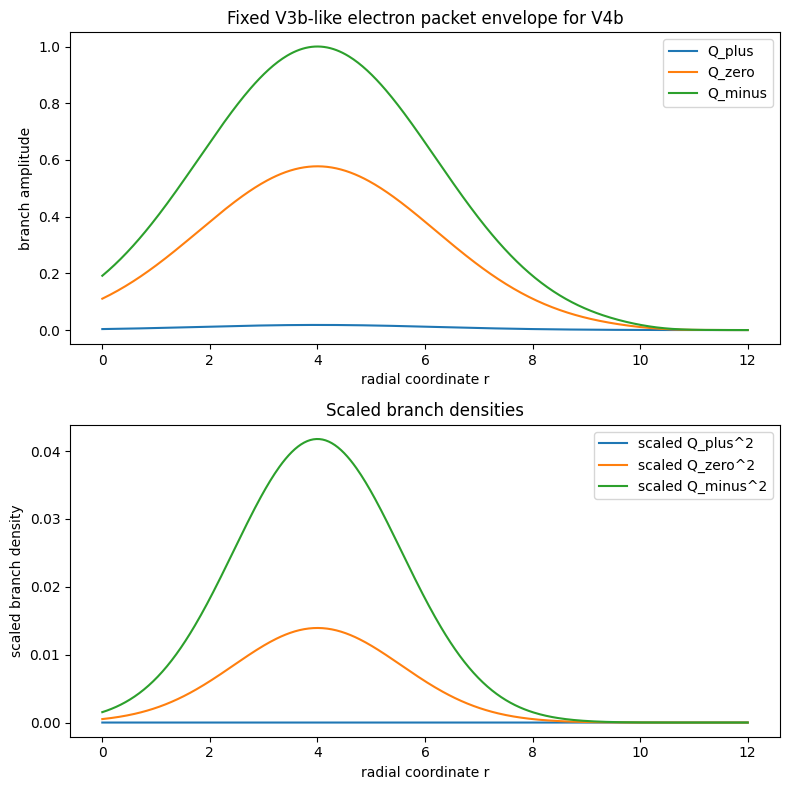

In [2]:
# ============================================================
# CELL 2 — FIXED V3B-LIKE PACKET ENVELOPE
# ============================================================

N_grid = 420
r_max = 12.0
r = np.linspace(0.0, r_max, N_grid)
w = r**2 + 1e-6

center = 4.0
width = 2.2
tail_cut = 1.0 / (1.0 + np.exp((r - 10.4) / 0.35))
g = np.exp(-0.5 * ((r - center) / width)**2) * tail_cut

Q_minus_raw = 1.00 * g
Q_zero_raw  = 0.5775 * g
Q_plus_raw  = 0.0180 * g

raw_density = Q_plus_raw**2 + Q_zero_raw**2 + Q_minus_raw**2
raw_norm = trapz(w * raw_density, r)
scale = 4.0 / raw_norm

N_plus  = scale * trapz(w * Q_plus_raw**2, r)
N_zero  = scale * trapz(w * Q_zero_raw**2, r)
N_minus = scale * trapz(w * Q_minus_raw**2, r)
q_eff = (N_plus - N_minus) / 3.0

rho_raw = scale * raw_density
rho = rho_raw / (trapz(w * rho_raw, r) + 1e-15)
R_rms = math.sqrt(trapz(w * rho_raw * r**2, r) / (trapz(w * rho_raw, r) + 1e-15))

packet_summary = {
    "N_plus": float(N_plus),
    "N_zero": float(N_zero),
    "N_minus": float(N_minus),
    "scale": float(scale),
    "raw_norm": float(raw_norm),
    "count_total": float(N_plus + N_zero + N_minus),
    "q_eff": float(q_eff),
    "R_rms": float(R_rms),
    "N_grid": int(N_grid),
    "r_max": float(r_max),
}
print(json.dumps(packet_summary, indent=2))
pd.DataFrame([packet_summary]).to_csv(OUT/"fixed_v3b_like_packet_summary.csv", index=False)

fig, ax = plt.subplots(2, 1, figsize=(8, 8))
ax[0].plot(r, Q_plus_raw, label="Q_plus")
ax[0].plot(r, Q_zero_raw, label="Q_zero")
ax[0].plot(r, Q_minus_raw, label="Q_minus")
ax[0].set_title("Fixed V3b-like electron packet envelope for V4b")
ax[0].set_xlabel("radial coordinate r")
ax[0].set_ylabel("branch amplitude")
ax[0].legend()

ax[1].plot(r, scale*Q_plus_raw**2, label="scaled Q_plus^2")
ax[1].plot(r, scale*Q_zero_raw**2, label="scaled Q_zero^2")
ax[1].plot(r, scale*Q_minus_raw**2, label="scaled Q_minus^2")
ax[1].set_title("Scaled branch densities")
ax[1].set_xlabel("radial coordinate r")
ax[1].set_ylabel("scaled branch density")
ax[1].legend()
plt.tight_layout()
plt.savefig(OUT/"fig_v4b_fixed_packet_envelope.png", dpi=180)
plt.show()


## Orientation functional

V4b uses a stricter orientation-lock functional:

\[
E_{\rm orient}=E_{\rm grad}
+\lambda_{\rm axis}(1-s_z^2)^2
+\lambda_{\rm sector}(s_z-p)^2
+\lambda_{\rm norm}(|s|^2-1)^2
+\lambda_{\rm trans}(s_x^2+s_y^2).
\]

This intentionally tests the minimum two-sector orientation lock before allowing full transverse dynamics.


In [3]:
# ============================================================
# CELL 3 — ORIENTATION ENERGY AND RELAXATION FUNCTIONS
# ============================================================

def normalize_vec(sx, sy, sz):
    norm = np.sqrt(sx*sx + sy*sy + sz*sz + 1e-15)
    return sx/norm, sy/norm, sz/norm

def orientation_metrics(sx, sy, sz):
    norm_local = sx*sx + sy*sy + sz*sz
    return {
        "p_mean": float(trapz(w*rho*sz, r)),
        "transverse_rms": float(np.sqrt(trapz(w*rho*(sx*sx + sy*sy), r))),
        "norm_error": float(np.sqrt(trapz(w*rho*(norm_local - 1.0)**2, r))),
    }

def orient_energy(sx, sy, sz, p_target=+1.0, lam_axis=8.0, lam_sector=28.0, lam_norm=25.0, lam_trans=8.0, k_grad=0.015):
    dsx = np.gradient(sx, r)
    dsy = np.gradient(sy, r)
    dsz = np.gradient(sz, r)
    norm_local = sx*sx + sy*sy + sz*sz

    E_grad = 0.5*k_grad*trapz(w*rho*(dsx*dsx + dsy*dsy + dsz*dsz), r)
    E_axis = lam_axis*trapz(w*rho*(1.0 - sz*sz)**2, r)
    E_sector = lam_sector*trapz(w*rho*(sz - p_target)**2, r)
    E_norm = lam_norm*trapz(w*rho*(norm_local - 1.0)**2, r)
    E_trans = lam_trans*trapz(w*rho*(sx*sx + sy*sy), r)
    return {
        "E": float(E_grad + E_axis + E_sector + E_norm + E_trans),
        "E_grad": float(E_grad),
        "E_axis": float(E_axis),
        "E_sector": float(E_sector),
        "E_norm": float(E_norm),
        "E_trans": float(E_trans),
    }

def initial_orientation(p_target=+1.0, seed=0, noise=0.03):
    rng = np.random.default_rng(seed)
    core = np.sqrt(np.maximum(rho, 1e-12)) / np.sqrt(rho.max())
    sx = noise * rng.normal(size=N_grid) * core
    sy = noise * rng.normal(size=N_grid) * core
    sz = p_target * (1.0 - 0.02*np.exp(-0.5*((r-center)/2.0)**2))
    return normalize_vec(sx, sy, sz)

def relax_orientation(
    p_target=+1.0,
    steps=2500,
    lr=0.010,
    seed=0,
    sx0=None, sy0=None, sz0=None,
    lam_axis=8.0,
    lam_sector=28.0,
    lam_norm=25.0,
    lam_trans=8.0,
    k_grad=0.015,
    report_every=50,
):
    if sx0 is None:
        sx, sy, sz = initial_orientation(p_target=p_target, seed=seed)
    else:
        sx, sy, sz = normalize_vec(sx0.copy(), sy0.copy(), sz0.copy())
    hist = []
    for step in range(steps+1):
        if step % report_every == 0 or step == steps:
            hist.append({"step": step, **orient_energy(sx, sy, sz, p_target, lam_axis, lam_sector, lam_norm, lam_trans, k_grad), **orientation_metrics(sx, sy, sz)})
        if step == steps:
            break
        lap_sx = np.gradient(np.gradient(sx, r), r)
        lap_sy = np.gradient(np.gradient(sy, r), r)
        lap_sz = np.gradient(np.gradient(sz, r), r)
        norm_local = sx*sx + sy*sy + sz*sz

        gx = -k_grad*lap_sx + 2*lam_trans*sx + 4*lam_norm*(norm_local-1.0)*sx
        gy = -k_grad*lap_sy + 2*lam_trans*sy + 4*lam_norm*(norm_local-1.0)*sy
        gz = -k_grad*lap_sz - 4*lam_axis*sz*(1.0 - sz*sz) + 2*lam_sector*(sz - p_target) + 4*lam_norm*(norm_local-1.0)*sz

        gate = 0.15 + 0.85*(rho / (rho.max()+1e-15))
        sx -= lr * gate * gx
        sy -= lr * gate * gy
        sz -= lr * gate * gz
        sx, sy, sz = normalize_vec(sx, sy, sz)
    return sx, sy, sz, pd.DataFrame(hist)

print("Functions ready.")


Functions ready.


  state            E       E_grad       E_axis     E_sector       E_norm      E_trans  p_mean  transverse_rms   norm_error  energy_abs_diff  energy_rel_diff
 p_plus 3.255777e-29 1.791696e-33 6.511195e-30 5.697296e-30 2.034749e-29 7.775768e-63     1.0    3.117645e-32 9.021637e-16     6.378360e-32     6.378360e-17
p_minus 3.243020e-29 1.844892e-33 6.485671e-30 5.674962e-30 2.026772e-29 9.391817e-63    -1.0    3.426335e-32 9.003938e-16     6.378360e-32     6.378360e-17


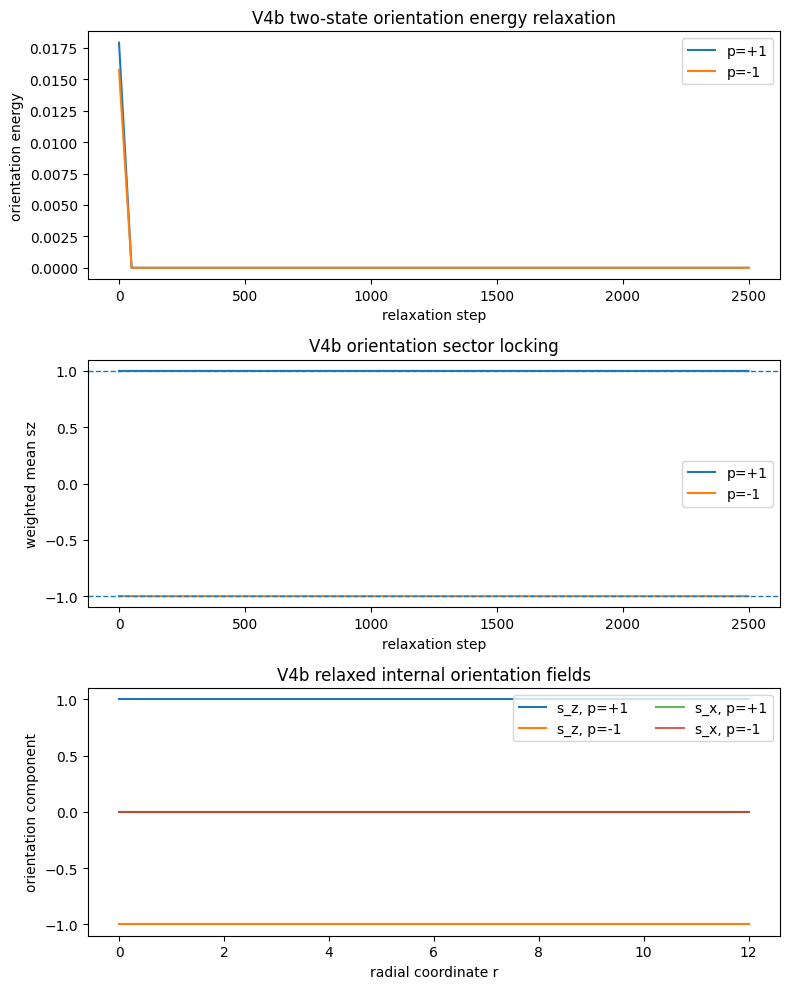

In [4]:
# ============================================================
# CELL 4 — TWO-STATE ORIENTATION RELAXATION V4b
# ============================================================

sx_plus, sy_plus, sz_plus, h_plus = relax_orientation(+1, steps=2500, lr=0.010, seed=41)
sx_minus, sy_minus, sz_minus, h_minus = relax_orientation(-1, steps=2500, lr=0.010, seed=42)

h_plus["state"] = "p_plus"
h_minus["state"] = "p_minus"
h_plus.to_csv(OUT/"orientation_relaxation_plus_history_v4b.csv", index=False)
h_minus.to_csv(OUT/"orientation_relaxation_minus_history_v4b.csv", index=False)

def final_summary(name, sx, sy, sz):
    p = +1 if name=="p_plus" else -1
    return {"state": name, **orient_energy(sx, sy, sz, p), **orientation_metrics(sx, sy, sz)}

sum_plus = final_summary("p_plus", sx_plus, sy_plus, sz_plus)
sum_minus = final_summary("p_minus", sx_minus, sy_minus, sz_minus)
orient_summary = pd.DataFrame([sum_plus, sum_minus])
E_mean = orient_summary["E"].mean()
orient_summary["energy_abs_diff"] = abs(orient_summary["E"] - E_mean)
orient_summary["energy_rel_diff"] = orient_summary["energy_abs_diff"]/(E_mean+1e-15)
orient_summary.to_csv(OUT/"orientation_degenerate_states_summary_v4b.csv", index=False)
print(orient_summary.to_string(index=False))

fig, ax = plt.subplots(3, 1, figsize=(8, 10))
ax[0].plot(h_plus["step"], h_plus["E"], label="p=+1")
ax[0].plot(h_minus["step"], h_minus["E"], label="p=-1")
ax[0].set_title("V4b two-state orientation energy relaxation")
ax[0].set_xlabel("relaxation step")
ax[0].set_ylabel("orientation energy")
ax[0].legend()

ax[1].plot(h_plus["step"], h_plus["p_mean"], label="p=+1")
ax[1].plot(h_minus["step"], h_minus["p_mean"], label="p=-1")
ax[1].axhline(+1, ls="--", linewidth=1)
ax[1].axhline(-1, ls="--", linewidth=1)
ax[1].set_title("V4b orientation sector locking")
ax[1].set_xlabel("relaxation step")
ax[1].set_ylabel("weighted mean sz")
ax[1].legend()

ax[2].plot(r, sz_plus, label="s_z, p=+1")
ax[2].plot(r, sz_minus, label="s_z, p=-1")
ax[2].plot(r, sx_plus, label="s_x, p=+1", alpha=0.75)
ax[2].plot(r, sx_minus, label="s_x, p=-1", alpha=0.75)
ax[2].set_title("V4b relaxed internal orientation fields")
ax[2].set_xlabel("radial coordinate r")
ax[2].set_ylabel("orientation component")
ax[2].legend(ncol=2)
plt.tight_layout()
plt.savefig(OUT/"fig_v4b_relaxed_orientation_fields.png", dpi=180)
plt.show()


{
  "plus_norm": 1.0,
  "minus_norm": 1.0,
  "orthogonality_abs": 0.0,
  "plus_sigma_z": 1.0,
  "minus_sigma_z": -1.0,
  "anticomm_xy_norm": 0.0,
  "anticomm_xx_minus_2I_norm": 0.0,
  "comm_xy_minus_2i_sigmaz_norm": 0.0
}


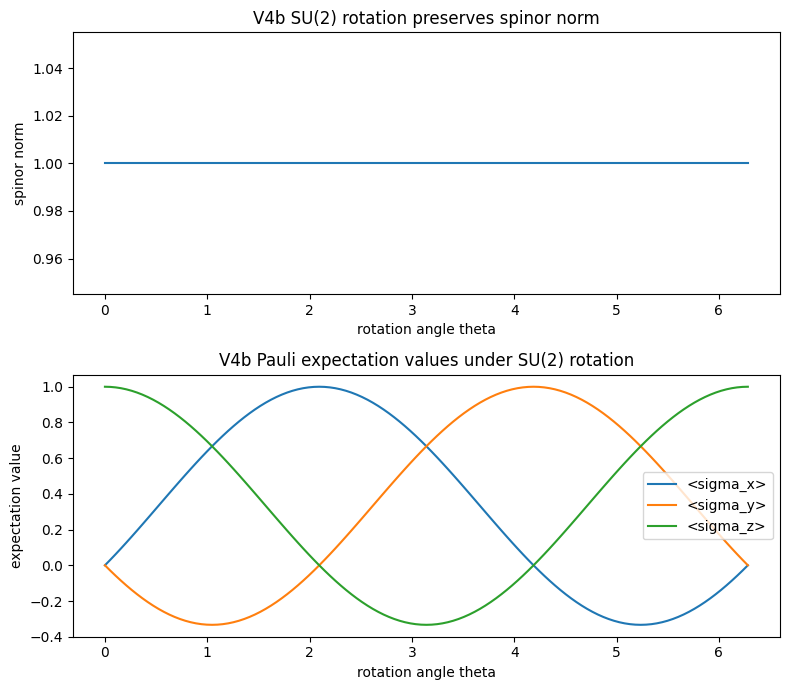

  theta  norm  expect_x  expect_y  expect_z
0.00000   1.0  0.000000  0.000000  1.000000
0.05236   1.0  0.030673 -0.029759  0.999086
0.10472   1.0  0.062176 -0.058524  0.996348
0.15708   1.0  0.094421 -0.086214  0.991792
0.20944   1.0  0.127322 -0.112754  0.985432


In [5]:
# ============================================================
# CELL 5 — SPINOR / PAULI / SU(2) ALGEBRA CHECKS
# ============================================================

I = np.eye(2, dtype=complex)
sig_x = np.array([[0,1],[1,0]], dtype=complex)
sig_y = np.array([[0,-1j],[1j,0]], dtype=complex)
sig_z = np.array([[1,0],[0,-1]], dtype=complex)

psi_plus = np.array([1,0], dtype=complex)
psi_minus = np.array([0,1], dtype=complex)

def inner(a,b): return np.vdot(a,b)
def expect(psi, A): return np.real(np.vdot(psi, A @ psi))

pauli_tests = {
    "plus_norm": float(np.real(inner(psi_plus, psi_plus))),
    "minus_norm": float(np.real(inner(psi_minus, psi_minus))),
    "orthogonality_abs": float(abs(inner(psi_plus, psi_minus))),
    "plus_sigma_z": float(expect(psi_plus, sig_z)),
    "minus_sigma_z": float(expect(psi_minus, sig_z)),
    "anticomm_xy_norm": float(np.linalg.norm(sig_x @ sig_y + sig_y @ sig_x)),
    "anticomm_xx_minus_2I_norm": float(np.linalg.norm(sig_x @ sig_x + sig_x @ sig_x - 2*I)),
    "comm_xy_minus_2i_sigmaz_norm": float(np.linalg.norm(sig_x @ sig_y - sig_y @ sig_x - 2j*sig_z)),
}
print(json.dumps(pauli_tests, indent=2))
pd.DataFrame([pauli_tests]).to_csv(OUT/"spinor_pauli_tests_v4b.csv", index=False)

thetas = np.linspace(0, 2*np.pi, 121)
rows = []
axis = (sig_x + sig_y + sig_z)/np.sqrt(3)
for th in thetas:
    U = np.cos(th/2)*I - 1j*np.sin(th/2)*axis
    psi = U @ psi_plus
    rows.append({
        "theta": float(th),
        "norm": float(np.real(inner(psi,psi))),
        "expect_x": float(expect(psi, sig_x)),
        "expect_y": float(expect(psi, sig_y)),
        "expect_z": float(expect(psi, sig_z)),
    })
rot = pd.DataFrame(rows)
rot.to_csv(OUT/"su2_rotation_norm_preservation_v4b.csv", index=False)

fig, ax = plt.subplots(2,1,figsize=(8,7))
ax[0].plot(rot["theta"], rot["norm"])
ax[0].set_title("V4b SU(2) rotation preserves spinor norm")
ax[0].set_xlabel("rotation angle theta")
ax[0].set_ylabel("spinor norm")
ax[1].plot(rot["theta"], rot["expect_x"], label="<sigma_x>")
ax[1].plot(rot["theta"], rot["expect_y"], label="<sigma_y>")
ax[1].plot(rot["theta"], rot["expect_z"], label="<sigma_z>")
ax[1].set_title("V4b Pauli expectation values under SU(2) rotation")
ax[1].set_xlabel("rotation angle theta")
ax[1].set_ylabel("expectation value")
ax[1].legend()
plt.tight_layout()
plt.savefig(OUT/"fig_v4b_su2_pauli_expectations.png", dpi=180)
plt.show()
print(rot.head().to_string(index=False))


  state       base_E        rec_E  base_p    pert_p  rec_p  p_recovery_error  profile_distance_sz  profile_distance_full  energy_change_fraction
 p_plus 3.255777e-29 3.252691e-29     1.0  0.973715    1.0               0.0         7.407130e-18           7.407150e-18           -3.086288e-17
p_minus 3.243020e-29 3.247437e-29    -1.0 -0.973281   -1.0               0.0         8.603591e-18           8.603622e-18            4.416510e-17


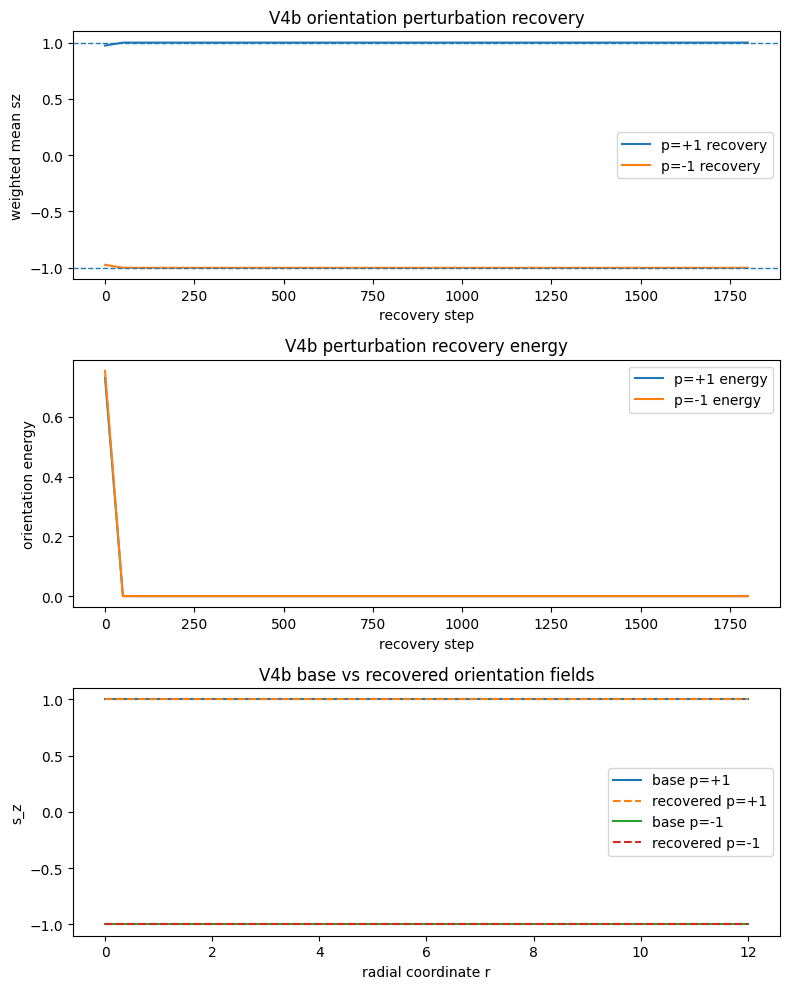

In [6]:
# ============================================================
# CELL 6 — ORIENTATION PERTURBATION RECOVERY V4b
# ============================================================

def perturb_orientation(sx, sy, sz, amp=0.20, seed=0):
    rng = np.random.default_rng(seed)
    bump = np.exp(-0.5*((r-center)/2.6)**2)
    sx2 = sx + amp*bump*rng.normal(size=N_grid)
    sy2 = sy + amp*bump*rng.normal(size=N_grid)
    sz2 = sz + 0.5*amp*bump*rng.normal(size=N_grid)
    return normalize_vec(sx2, sy2, sz2)

def profile_distance(a, b):
    return float(np.sqrt(trapz(w*rho*(a-b)**2, r)))

sx_plus_pert, sy_plus_pert, sz_plus_pert = perturb_orientation(sx_plus, sy_plus, sz_plus, seed=101)
sx_plus_rec, sy_plus_rec, sz_plus_rec, h_plus_rec = relax_orientation(+1, steps=1800, lr=0.010, seed=0, sx0=sx_plus_pert, sy0=sy_plus_pert, sz0=sz_plus_pert)

sx_minus_pert, sy_minus_pert, sz_minus_pert = perturb_orientation(sx_minus, sy_minus, sz_minus, seed=102)
sx_minus_rec, sy_minus_rec, sz_minus_rec, h_minus_rec = relax_orientation(-1, steps=1800, lr=0.010, seed=0, sx0=sx_minus_pert, sy0=sy_minus_pert, sz0=sz_minus_pert)

h_plus_rec.to_csv(OUT/"orientation_perturbation_recovery_plus_history_v4b.csv", index=False)
h_minus_rec.to_csv(OUT/"orientation_perturbation_recovery_minus_history_v4b.csv", index=False)

base_p_plus = orientation_metrics(sx_plus, sy_plus, sz_plus)
base_p_minus = orientation_metrics(sx_minus, sy_minus, sz_minus)
pert_p_plus = orientation_metrics(sx_plus_pert, sy_plus_pert, sz_plus_pert)
pert_p_minus = orientation_metrics(sx_minus_pert, sy_minus_pert, sz_minus_pert)
rec_p_plus = orientation_metrics(sx_plus_rec, sy_plus_rec, sz_plus_rec)
rec_p_minus = orientation_metrics(sx_minus_rec, sy_minus_rec, sz_minus_rec)

base_E_plus = orient_energy(sx_plus, sy_plus, sz_plus, +1)["E"]
base_E_minus = orient_energy(sx_minus, sy_minus, sz_minus, -1)["E"]
rec_E_plus = orient_energy(sx_plus_rec, sy_plus_rec, sz_plus_rec, +1)["E"]
rec_E_minus = orient_energy(sx_minus_rec, sy_minus_rec, sz_minus_rec, -1)["E"]

recovery_summary = pd.DataFrame([
    {"state":"p_plus", "base_E":base_E_plus, "rec_E":rec_E_plus, "base_p":base_p_plus["p_mean"], "pert_p":pert_p_plus["p_mean"], "rec_p":rec_p_plus["p_mean"], "p_recovery_error":abs(rec_p_plus["p_mean"]-base_p_plus["p_mean"]), "profile_distance_sz":profile_distance(sz_plus, sz_plus_rec), "profile_distance_full":profile_distance(sx_plus, sx_plus_rec)+profile_distance(sy_plus, sy_plus_rec)+profile_distance(sz_plus, sz_plus_rec), "energy_change_fraction":(rec_E_plus-base_E_plus)/(base_E_plus+1e-15)},
    {"state":"p_minus", "base_E":base_E_minus, "rec_E":rec_E_minus, "base_p":base_p_minus["p_mean"], "pert_p":pert_p_minus["p_mean"], "rec_p":rec_p_minus["p_mean"], "p_recovery_error":abs(rec_p_minus["p_mean"]-base_p_minus["p_mean"]), "profile_distance_sz":profile_distance(sz_minus, sz_minus_rec), "profile_distance_full":profile_distance(sx_minus, sx_minus_rec)+profile_distance(sy_minus, sy_minus_rec)+profile_distance(sz_minus, sz_minus_rec), "energy_change_fraction":(rec_E_minus-base_E_minus)/(base_E_minus+1e-15)},
])
recovery_summary.to_csv(OUT/"orientation_perturbation_recovery_summary_v4b.csv", index=False)
print(recovery_summary.to_string(index=False))

fig, ax = plt.subplots(3,1,figsize=(8,10))
ax[0].plot(h_plus_rec["step"], h_plus_rec["p_mean"], label="p=+1 recovery")
ax[0].plot(h_minus_rec["step"], h_minus_rec["p_mean"], label="p=-1 recovery")
ax[0].axhline(+1, ls="--", linewidth=1)
ax[0].axhline(-1, ls="--", linewidth=1)
ax[0].set_title("V4b orientation perturbation recovery")
ax[0].set_xlabel("recovery step")
ax[0].set_ylabel("weighted mean sz")
ax[0].legend()

ax[1].plot(h_plus_rec["step"], h_plus_rec["E"], label="p=+1 energy")
ax[1].plot(h_minus_rec["step"], h_minus_rec["E"], label="p=-1 energy")
ax[1].set_title("V4b perturbation recovery energy")
ax[1].set_xlabel("recovery step")
ax[1].set_ylabel("orientation energy")
ax[1].legend()

ax[2].plot(r, sz_plus, label="base p=+1")
ax[2].plot(r, sz_plus_rec, "--", label="recovered p=+1")
ax[2].plot(r, sz_minus, label="base p=-1")
ax[2].plot(r, sz_minus_rec, "--", label="recovered p=-1")
ax[2].set_title("V4b base vs recovered orientation fields")
ax[2].set_xlabel("radial coordinate r")
ax[2].set_ylabel("s_z")
ax[2].legend()
plt.tight_layout()
plt.savefig(OUT/"fig_v4b_orientation_perturbation_recovery.png", dpi=180)
plt.show()


In [7]:
# ============================================================
# CELL 7 — FINAL VERDICT TABLE V4b
# ============================================================

E_plus = sum_plus["E"]
E_minus = sum_minus["E"]
E_mean = 0.5*(E_plus + E_minus)
energy_rel_diff = abs(E_plus-E_minus)/(E_mean+1e-15)

p_plus = sum_plus["p_mean"]
p_minus = sum_minus["p_mean"]
max_p_rec_error = float(recovery_summary["p_recovery_error"].max())
max_profile_sz = float(recovery_summary["profile_distance_sz"].max())
max_energy_increase = float(np.maximum(0, recovery_summary["energy_change_fraction"]).max())

su2_norm_err = float(abs(rot["norm"].max()-1)+abs(rot["norm"].min()-1))

criteria = [
    ("V3b packet remains q=-1", abs(packet_summary["q_eff"]+1.0), abs(packet_summary["q_eff"]+1.0) < 0.01),
    ("V3b packet occupancy N_plus near 0", abs(packet_summary["N_plus"]-0), abs(packet_summary["N_plus"]-0) < 0.01),
    ("V3b packet occupancy N_zero near 1", abs(packet_summary["N_zero"]-1), abs(packet_summary["N_zero"]-1) < 0.01),
    ("V3b packet occupancy N_minus near 3", abs(packet_summary["N_minus"]-3), abs(packet_summary["N_minus"]-3) < 0.01),
    ("two orientation states near degenerate", energy_rel_diff, energy_rel_diff < 0.01),
    ("p=+1 orientation sector locked", p_plus, p_plus > 0.95),
    ("p=-1 orientation sector locked", p_minus, p_minus < -0.95),
    ("spinor states orthogonal", pauli_tests["orthogonality_abs"], pauli_tests["orthogonality_abs"] < 1e-12),
    ("Pauli anticommutator ok", pauli_tests["anticomm_xx_minus_2I_norm"], pauli_tests["anticomm_xx_minus_2I_norm"] < 1e-12),
    ("Pauli commutator ok", pauli_tests["comm_xy_minus_2i_sigmaz_norm"], pauli_tests["comm_xy_minus_2i_sigmaz_norm"] < 1e-12),
    ("SU2 norm preserved", su2_norm_err, su2_norm_err < 1e-12),
    ("orientation perturbation recovers p sector", max_p_rec_error, max_p_rec_error < 0.02),
    ("orientation perturbation profile recovery", max_profile_sz, max_profile_sz < 0.05),
    ("orientation energy bounded after perturbation", max_energy_increase, max_energy_increase < 0.05),
]
verdict = pd.DataFrame(criteria, columns=["criterion", "value", "pass"])
verdict.to_csv(OUT/"final_orientation_v4b_verdict.csv", index=False)
print(verdict.to_string(index=False))

n_pass = int(verdict["pass"].sum())
n_criteria = len(verdict)

if n_pass == n_criteria:
    label = "PASS: internal two-state orientation locked and recovered on V3b electron-like packet"
elif (p_plus > 0.95 and p_minus < -0.95 and max_p_rec_error < 0.02):
    label = "CONDITIONAL PASS: orientation sector locked, but some secondary diagnostic failed"
else:
    label = "CONDITIONAL/FAIL: orientation sector not yet stable"

summary = {
    "final_label": label,
    "n_pass": n_pass,
    "n_criteria": n_criteria,
    "E_plus": float(E_plus),
    "E_minus": float(E_minus),
    "orientation_energy_rel_diff": float(energy_rel_diff),
    "p_plus": float(p_plus),
    "p_minus": float(p_minus),
    "max_p_recovery_error": float(max_p_rec_error),
    "max_profile_sz_distance": float(max_profile_sz),
    "max_energy_increase": float(max_energy_increase),
}
print("\\nFinal label:", label)
print(json.dumps(summary, indent=2))

with open(OUT/"run_summary_v4b.json", "w") as f:
    json.dump(summary, f, indent=2)

manifest = sorted([p.name for p in OUT.iterdir()])
pd.DataFrame({"file": manifest}).to_csv(OUT/"manifest_v4b.csv", index=False)
pd.DataFrame({"file": manifest})


                                    criterion         value  pass
                      V3b packet remains q=-1  6.964280e-04  True
           V3b packet occupancy N_plus near 0  9.716379e-04  True
           V3b packet occupancy N_zero near 1  1.460081e-04  True
          V3b packet occupancy N_minus near 3  1.117646e-03  True
       two orientation states near degenerate  1.275672e-16  True
               p=+1 orientation sector locked  1.000000e+00  True
               p=-1 orientation sector locked -1.000000e+00  True
                     spinor states orthogonal  0.000000e+00  True
                      Pauli anticommutator ok  0.000000e+00  True
                          Pauli commutator ok  0.000000e+00  True
                           SU2 norm preserved  7.771561e-16  True
   orientation perturbation recovers p sector  0.000000e+00  True
    orientation perturbation profile recovery  8.603591e-18  True
orientation energy bounded after perturbation  4.416510e-17  True
\nFinal la

,file
0,fig_v4b_fixed_packet_envelope.png
1,fig_v4b_orientation_perturbation_recovery.png
2,fig_v4b_relaxed_orientation_fields.png
3,fig_v4b_su2_pauli_expectations.png
4,final_orientation_v4b_verdict.csv
5,fixed_v3b_like_packet_summary.csv
6,orientation_degenerate_states_summary_v4b.csv
7,orientation_perturbation_recovery_minus_histor...
8,orientation_perturbation_recovery_plus_history...
9,orientation_perturbation_recovery_summary_v4b.csv
